In [1]:
import requests
import torch

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
text = requests.get(url).text
print(f"dataset length: {len(text):,} characters")
print(text[:300])

# character-level tokenizer
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(f"vocab size: {vocab_size}")

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

def encode(s):
    return [stoi[c] for c in s]

def decode(ids):
    return ''.join(itos[i] for i in ids)

# encode entire dataset into one long tensor of ints
data = torch.tensor(encode(text), dtype=torch.long)
print(f"encoded data shape: {data.shape}")

#train/val split
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]
print(f"train tokens: {len(train_data):,}  val tokens: {len(val_data):,}")


# batch sampler: pulls random (B, T) chunks for next-char prediction
def get_batch(split, B, T):
    d = train_data if split == "train" else val_data
    # pick B random starting points, each chunk T+1 long (T input + 1 shifted target)
    ix = torch.randint(0, len(d) - T - 1, (B,))
    x = torch.stack([d[i:i+T] for i in ix])
    y = torch.stack([d[i+1:i+T+1] for i in ix])
    # x shape: (B, T)   y shape: (B, T) — y is x shifted by ONE position
    return x, y


xb, yb = get_batch("train", B=4, T=16)
print("input :", decode(xb[0].tolist()))
print("target:", decode(yb[0].tolist()))


dataset length: 1,115,394 characters
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us
vocab size: 65
encoded data shape: torch.Size([1115394])
train tokens: 1,003,854  val tokens: 111,540
input : I know not, nor 
target:  know not, nor I


In [2]:
import torch
import torch.nn as nn

# intialize all part of MoE
class Expert(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.act = nn.ReLU()

    def forward(self, x):
        x = self.act(self.fc1(x))
        x = self.fc2(x)
        return x


class Router(nn.Module):
    def __init__(self, top_k, d_model, n_experts):
        super().__init__()
        self.top_k = top_k
        self.W_g = nn.Linear(d_model, n_experts, bias=False)

    def forward(self, x):
        logits = self.W_g(x)
        top_vals, top_idx = torch.topk(logits, self.top_k, dim=-1)
        mask = torch.full_like(logits, float('-inf'))
        mask.scatter_(-1, top_idx, top_vals)
        weights = torch.softmax(mask, dim=-1)
        return weights, top_idx


class MoELayer(nn.Module):
    def __init__(self, d_model, d_ff, n_experts, top_k):
        super().__init__()
        self.n_experts = n_experts
        self.top_k = top_k
        self.router = Router(top_k=top_k, d_model=d_model, n_experts=n_experts)
        self.experts = nn.ModuleList([
            Expert(d_model, d_ff) for _ in range(n_experts)
        ])

    def forward(self, x):
        B, T, D = x.shape
        x_flat = x.view(B * T, D)
        weights, top_idx = self.router(x_flat)

        out = torch.zeros_like(x_flat)
        for e_idx in range(self.n_experts):
            mask = (top_idx == e_idx).any(dim=-1)
            if not mask.any():
                continue
            tokens = x_flat[mask]
            expert_out = self.experts[e_idx](tokens)
            gate = weights[mask, e_idx].unsqueeze(-1)
            out[mask] += gate * expert_out
        return out.view(B, T, D), weights, top_idx

class MoEModel(nn.Module):
    def __init__(self, d_model, d_ff, n_experts, top_k, vocab_size):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model)
        self.moe1 = MoELayer(d_model, d_ff, n_experts, top_k)
        self.moe2 = MoELayer(d_model, d_ff, n_experts, top_k)
        self.out_proj = nn.Linear(d_model, vocab_size)

    def forward(self, token_ids):

        x = self.embed(token_ids)

        x, w1, idx1 = self.moe1(x)

        x, w2, idx2 = self.moe2(x)

        logits = self.out_proj(x)


        return logits, [(w1, idx1), (w2, idx2)]



def cv_squared(x):
    return x.var() / (x.mean() ** 2 + 1e-8)


def aux_loss_for_layer(weights, top_idx, n_experts):
    importance = weights.sum(dim=0)
    imp_loss = cv_squared(importance)

    load = torch.zeros(n_experts)
    for e in range(n_experts):
        load[e] = (top_idx == e).sum().float()
    load_loss = cv_squared(load)

    return imp_loss + load_loss


In [3]:
import matplotlib.pyplot as plt
import numpy as np



d_model = 128
d_ff = 512
n_experts = 8
top_k = 2
B, T = 32, 64

model = MoEModel(d_model, d_ff, n_experts, top_k, vocab_size)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
criterion = nn.CrossEntropyLoss()


@torch.no_grad()
def estimate_val_loss(n_batches=20):
    model.eval()
    losses = []
    for _ in range(n_batches):
        xb, yb = get_batch("val", B, T)
        logits, _ = model(xb)
        loss = criterion(logits.view(-1, logits.size(-1)), yb.view(-1))
        losses.append(loss.item())
    model.train()
    return sum(losses) / len(losses)


n_steps = 1000
history = {
    "train_loss": [], "val_loss": [], "val_steps": [],
    "expert_load_moe1": [], "expert_load_moe2": [],
}

for step in range(n_steps):
    optimizer.zero_grad()

    xb, yb = get_batch("train", B, T)
    # xb: (B, T)   yb: (B, T)

    logits, aux_data = model(xb)
    # logits: (B, T, vocab_size)

    ce_loss = criterion(logits.view(-1, logits.size(-1)), yb.view(-1))

    total_aux = 0
    for weights, top_idx in aux_data:
        total_aux += aux_loss_for_layer(weights, top_idx, n_experts=n_experts)

    loss = ce_loss + 0.01 * total_aux
    loss.backward()
    optimizer.step()

    history["train_loss"].append(loss.item())

    for layer_name, (weights, top_idx) in zip(["expert_load_moe1", "expert_load_moe2"], aux_data):
        load = torch.zeros(n_experts)
        for e in range(n_experts):
            load[e] = (top_idx == e).sum().float()
        history[layer_name].append(load.detach().numpy())

    if step % 100 == 0 or step == n_steps - 1:
        val_loss = estimate_val_loss()
        history["val_loss"].append(val_loss)
        history["val_steps"].append(step)
        print(f"step {step:4d} | train loss {loss.item():.4f} | val loss {val_loss:.4f}")


random_baseline = torch.log(torch.tensor(float(vocab_size))).item()
print(f"\nrandom-guess baseline loss (ln(vocab_size)): {random_baseline:.4f}")
print(f"your final val loss: {history['val_loss'][-1]:.4f}")
if history["val_loss"][-1] < random_baseline:
    print("✓ model is learning something better than random")
else:
    print("✗ model is not beating random guessing yet — needs more steps")


# generate sample text — the real qualitative eval everyone does

@torch.no_grad()
def generate(model, start_text, max_new_tokens=200):
    model.eval()
    ids = torch.tensor([encode(start_text)], dtype=torch.long)
    for _ in range(max_new_tokens):
        context = ids[:, -T:]  # keep last T chars as context
        logits, _ = model(context)
        next_logits = logits[0, -1, :]  # (vocab_size,) — last position only
        probs = torch.softmax(next_logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)
        ids = torch.cat([ids, next_id.unsqueeze(0)], dim=1)
    model.train()
    return decode(ids[0].tolist())

print("\n--- Generated sample ---")
print(generate(model, "ROMEO:", max_new_tokens=200))


step    0 | train loss 4.1927 | val loss 4.1637
step  100 | train loss 2.5954 | val loss 2.5471
step  200 | train loss 2.4997 | val loss 2.4966
step  300 | train loss 2.5176 | val loss 2.4939
step  400 | train loss 2.4968 | val loss 2.4995
step  500 | train loss 2.5176 | val loss 2.4903
step  600 | train loss 2.4400 | val loss 2.4963
step  700 | train loss 2.4895 | val loss 2.5063
step  800 | train loss 2.4518 | val loss 2.5008
step  900 | train loss 2.4372 | val loss 2.5012
step  999 | train loss 2.4652 | val loss 2.4960

random-guess baseline loss (ln(vocab_size)): 4.1744
your final val loss: 2.4960
✓ model is learning something better than random

--- Generated sample ---
ROMEO:
'd, itis ked myofe, that t me be helad 't ar mer t eand thy, yowe Ve
GBENGBurto o darod sheis otlloulane w tcrris f gous; be medounyamenvefatheidrpat t withatutounthichottove cha'd.
PETha my ncour us


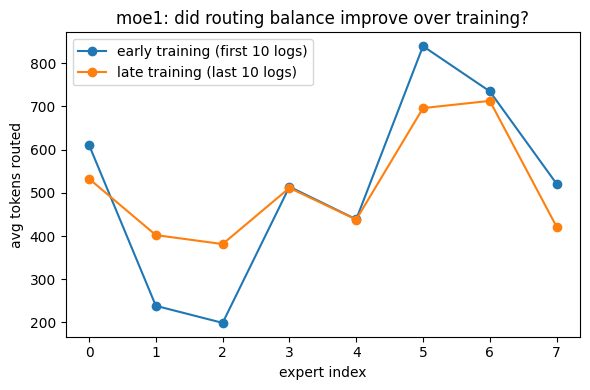


--- Dead expert check ---
expert_load_moe1: dead experts = none — all experts used
expert_load_moe1: total tokens per expert over training = [573536.0, 355260.0, 299744.0, 523517.0, 506389.0, 693934.0, 734843.0, 408777.0]
expert_load_moe2: dead experts = none — all experts used
expert_load_moe2: total tokens per expert over training = [673869.0, 474615.0, 522097.0, 433263.0, 523266.0, 470787.0, 468878.0, 529225.0]

--- Routing entropy (fresh val batch) ---
moe1 avg entropy: 0.6100
moe2 avg entropy: 0.4334
(max possible entropy for k=2 experts ≈ 0.6931)

--- Summary ---
final val loss: 2.4960  vs  random baseline: 4.1744
beats random baseline: yes
any dead experts: no — all experts contributing


In [4]:
import torch


def cv_squared(x):
    return x.var() / (x.mean() ** 2 + 1e-8)


# DIAGNOSTIC 1 — utilization over time: early vs late training

early_avg = torch.from_numpy(
    __import__("numpy").array(history["expert_load_moe1"][:10])
).float().mean(dim=0)
late_avg = torch.from_numpy(
    __import__("numpy").array(history["expert_load_moe1"][-10:])
).float().mean(dim=0)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(early_avg.numpy(), marker='o', label="early training (first 10 logs)")
ax.plot(late_avg.numpy(), marker='o', label="late training (last 10 logs)")
ax.set_title("moe1: did routing balance improve over training?")
ax.set_xlabel("expert index")
ax.set_ylabel("avg tokens routed")
ax.legend()
plt.tight_layout()
plt.savefig("moe_utilization_over_time.png", dpi=100)
plt.show()



# DIAGNOSTIC 2 — dead expert check

print("\n--- Dead expert check ---")
for layer_name in ["expert_load_moe1", "expert_load_moe2"]:
    total_load = torch.from_numpy(
        __import__("numpy").array(history[layer_name])
    ).sum(dim=0)
    dead = (total_load == 0).nonzero().flatten().tolist()
    print(f"{layer_name}: dead experts = {dead if dead else 'none — all experts used'}")
    print(f"{layer_name}: total tokens per expert over training = {total_load.tolist()}")


# DIAGNOSTIC 3 — routing entropy on a fresh real batch

def routing_entropy(weights):
    eps = 1e-9
    ent = -(weights * torch.log(weights + eps)).sum(dim=-1)  # (B*T,)
    return ent.mean().item()

xb_check, yb_check = get_batch("val", B, T)
with torch.no_grad():
    _, aux_data_check = model(xb_check)

w1_check, _ = aux_data_check[0]
w2_check, _ = aux_data_check[1]

print("\n--- Routing entropy (fresh val batch) ---")
print(f"moe1 avg entropy: {routing_entropy(w1_check):.4f}")
print(f"moe2 avg entropy: {routing_entropy(w2_check):.4f}")
print(f"(max possible entropy for k={top_k} experts ≈ "
      f"{torch.log(torch.tensor(float(top_k))).item():.4f})")


# DIAGNOSTIC 4 — summary verdict

print("\n--- Summary ---")
final_val = history["val_loss"][-1]
print(f"final val loss: {final_val:.4f}  vs  random baseline: {random_baseline:.4f}")
print(f"beats random baseline: {'yes' if final_val < random_baseline else 'no'}")

any_dead = any(
    (torch.from_numpy(__import__("numpy").array(history[ln])).sum(dim=0) == 0).any().item()
    for ln in ["expert_load_moe1", "expert_load_moe2"]
)
print(f"any dead experts: {'yes — investigate' if any_dead else 'no — all experts contributing'}")
